In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pickle
import tushare as ts

from glob import glob
from datetime import datetime
from typing import Union

import empyrical as ep
import scipy.stats as st

from tqdm import tqdm_notebook
from matplotlib import rcParams

rcParams['font.family'] = ['stHeiti']
# 用来正常显示负号
plt.rcParams['axes.unicode_minus'] = False
# 图表主题
plt.style.use('ggplot')

DATA_DIR = './smart_money_export'

In [2]:
def _load_schedule():
   """读取本地 schedule.csv，返回 calc_date（月末）与 rebalance_date（月初）的映射表"""
   path = os.path.join(DATA_DIR, 'schedule.csv')
   if not os.path.exists(path):
       raise FileNotFoundError(f"找不到日程表：{path}")
   
   schedule = pd.read_csv(path)
   schedule['calc_date'] = pd.to_datetime(schedule['calc_date'])
   schedule['rebalance_date'] = pd.to_datetime(schedule['rebalance_date'])
   return schedule

def _get_local_stockpool(watch_date: str):
    """从本地 min30 文件读取已过滤的股票池"""
    filepath = os.path.join(DATA_DIR, f'min30_{watch_date}.pkl')
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"找不到数据文件：{filepath}")
    
    with open(filepath, 'rb') as f:
        package = pd.read_pickle(f)
    return package['stock_pool']


def _get_local_close(stock_pool: list, date: str):
    """
    从本地数据获取某日期某股票池的收盘价
    """
    date_str = str(date)[:10]
    

    close_path = os.path.join(DATA_DIR, 'rebalance_close.pkl')
    if os.path.exists(close_path):
        close_df = pd.read_pickle(close_path)
        df = close_df[(close_df['date'] == date_str) & (close_df['code'].isin(stock_pool))]
        if len(df) > 0:
            return df.set_index('code')[['close']]


In [3]:
# 因子计算
def Smart_Strategy(start:str,end:str,factor:callable,grid_func_params:dict,mod:str = 'normal')-> pd.DataFrame:
    schedule = _load_schedule()
    # 筛选计算日期范围
    mask = (schedule['calc_date'] >= pd.to_datetime(start)) & (schedule['calc_date'] <= pd.to_datetime(end))
    schedule = schedule[mask].copy().reset_index(drop=True)
    
    if len(schedule) == 0:
       raise ValueError(f"在 {start} ~ {end} 范围内没有找到本地数据")
    
    # periods 现在明确是"月末因子计算日"列表
    calc_dates = schedule['calc_date'].tolist()
    rebalance_dates = schedule['rebalance_date'].tolist()

    factor_dic = {}
    for i in tqdm_notebook(range(len(calc_dates)), total=len(calc_dates), desc='因子计算'):
        tradeDate = calc_dates[i]           # 月末：因子计算日
        rebalance_date = rebalance_dates[i]  # 月初：实际调仓日（买入）
        
        # 收益终点是"下一调仓日"（卖出），而非下个月末
        if i + 1 >= len(rebalance_dates):
           break  # 最后一期没有下一调仓日，无法计算持有收益
        
        next_rebalance = rebalance_dates[i + 1]
        
        calc_str = tradeDate.strftime('%Y-%m-%d')
        rebalance_str = rebalance_date.strftime('%Y-%m-%d')
        next_rebalance_str = next_rebalance.strftime('%Y-%m-%d')
        
        # 获取股票池
        stock_pool = _get_local_stockpool(calc_str)
        
        # 获取因子类
        f = factor(stock_pool, watch_date=calc_str, mod=mod)
        # 初始化类
        f.get_data()
        # 批量计算因子
        factor_frame = grid_func_params['func'](f,**grid_func_params['params'])
        # 计算收益率
        close = _get_local_close(stock_pool, rebalance_str)
        next_close = _get_local_close(stock_pool, next_rebalance_str)      
        
        next_return = next_close/close -1

        # 直接列赋值，100% 确保 next_ret 列存在，不受 pd.concat 边界行为影响
        temp = factor_frame.copy()
        temp['next_ret'] = next_return.reindex(factor_frame.index)
        
        # 防御：如果该月 factor_frame 为空（0行），确保至少有个空壳
        if len(temp) == 0 and len(factor_frame.index) == 0:
            temp = pd.DataFrame({'next_ret': next_return})

            
        factor_dic[tradeDate] = temp
    factor_df = pd.concat(factor_dic,sort = True)
    factor_df.index.names = ['time','code']
    return factor_df

In [4]:
class Q_factor():
    def __init__(self,securities:Union[str,list],watch_date:str,N:int=10,frequency:str='30m',mod:str='normal'):
        self.securities = securities
        self.watch_date = watch_date
        self.N = N
        self.frequency = frequency
        self.mod = mod
        self.kline = self.N * 240 /int(self.frequency[:-1]) 

    def get_data(self)->pd.DataFrame:
    # 构造本地文件路径
        filepath = os.path.join(DATA_DIR, f'min30_{self.watch_date}.pkl')
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"本地数据文件不存在：{filepath}")
        
        # 读取本地 pkl（导出时已含 stock_pool + data）
        with open(filepath, 'rb') as f:
            package = pd.read_pickle(f)
        
        df = package['data'].copy()

        df = df[['time', 'code', 'open', 'close', 'volume']]
        
        # 按股票分组，取每只股票的最后 self.kline 条（最接近 watch_date 的）
        # 因为本地数据已按时间升序排列，直接 tail 即可
        df = df.groupby('code', group_keys=False).tail(int(self.kline))
        
        self.data = df.reset_index(drop=True)

    def calc(self,beta:float)->pd.Series:
        self.beta = round(beta,2)
        data = self.data[self.data!=0]
        open_df = data.pivot(index='time', columns='code', values='open')
        close_df = data.pivot(index='time', columns='code', values='close')
        volume_df = data.pivot(index='time', columns='code', values='volume')
        ret_df = close_df - open_df
        abs_ret_df = ret_df.abs()

        if self.mod =='normal':
            S = abs_ret_df/ volume_df.pow(beta)
        else:
            S = abs_ret_df / np.log(volume_df)

        S_rank = S.rank(ascending = False)
        concat_df = pd.concat((S_rank.stack(),close_df.stack(),volume_df.stack()),axis = 1,sort = True)
        concat_df.columns = ['rank','close','vol']

        ser = concat_df.groupby(level= 'code').apply(self.calc_Q)
        ser.name = self.name
        return ser

    def calc_Q(self,df:pd.DataFrame)-> float:
        df = df.copy()
        df = df.reset_index().set_index('rank').sort_index()
        df['cum_vol'] = df['vol'].cumsum()
        cum_sum = df['cum_vol']/df['vol'].sum()
        cond = cum_sum <= 0.2
        if (df[cond].empty) or (cum_sum.iloc[0] > 0.2):
            df1 = df.iloc[:1, :]
        else:
            df1 = df[cond]

            
        vol1_sum = df1['vol'].sum()
        if vol1_sum == 0:
            return np.nan
        price_w1 = np.average(df1['close'],weights = df1['vol'])
        price_w = np.average(df['close'],weights = df['vol'])

        if price_w == 0:
            return np.nan

        return price_w1/price_w
        
    @property    
    def name(self)->str:
        return f'Q_{self.N}_{self.frequency}_{self.beta}'        


def grid_factor(factor:callable,lamb:Union[str,list])->pd.DataFrame:
    if isinstance(lamb, (int, float)):
        lamb = [lamb]
    df_beta = []
    for l in lamb:
        df_beta.append(factor.calc(l))
    return pd.concat(df_beta,axis =1,sort= True)

In [51]:
# 计算ic
def ic(df: pd.DataFrame) -> pd.Series:
    f = [i for i in df.columns if i != 'next_ret']
    
    def _calc_ic(col):
        # 配对删除：只保留因子和收益都不为 NaN 的行
        mask = col.notna() & df['next_ret'].notna()
        
        # 有效样本不足 2 个，无法计算秩相关
        if mask.sum() < 2:
            return np.nan
        
        return st.spearmanr(col[mask], df['next_ret'][mask])[0]
    
    _ic = df[f].apply(_calc_ic)
    return _ic

# 分组
def add_group(ser:pd.Series , N:int=5)-> pd.Series:
    name = [f'G{i}' for i in range(1,N+1)]
    return pd.qcut(ser,N,labels = name,duplicates = 'drop')

#计算多空收益
def get_excess_ret(factor_df:pd.DataFrame,col:list)-> pd.DataFrame:
    if isinstance(col,(float,int,str)):
        col = [col]
    excess_ser = []

    for x in col:
        ser = factor_df.groupby(level='time')[x].transform(add_group)       
        ret_df = pd.concat((ser,factor_df['next_ret']),axis=1,sort= True)
        ret_df = ret_df.reset_index().pivot_table(index='time',columns =x,values='next_ret')
        excess_ser.append(ret_df['G1']-ret_df['G5'])
    excess_ret = pd.concat(excess_ser,axis=1,sort=True)
    excess_ret.columns=col
    return excess_ret


# 计算风险指标
def risk_indicator_tear(returns:pd.DataFrame,period:str='monthly')->pd.DataFrame:
    tear = pd.DataFrame()
    tear['annual_return'] = ep.annual_return(returns,period)
    tear['annual_volatility'] = ep.annual_volatility(returns,period)
    tear['max_drawdown'] = ep.max_drawdown(returns)

    if 'benchmark' in returns.columns:
    
        select_col = [col for col in returns.columns if col != 'benchmark']

        tear['IR'] = returns[select_col].apply(lambda x: information_ratio(x, returns['benchmark']))
    return tear
    
def information_ratio(ser1,ser2):
    active_return = ser1-ser2
    tracking_error = np.std(active_return, ddof=1)
    if np.isnan(tracking_error):
        return 0.0
    if tracking_error == 0:
        return np.nan
    return np.mean(active_return) / tracking_error


# def _get_local_benchmark(start: str, end: str) -> pd.DataFrame:
#     """
#     读取本地基准
#     """
#     date_start = pd.to_datetime(start)
#     date_end = pd.to_datetime(end)
#
#
#     close_path = os.path.join(DATA_DIR, 'rebalance_close.pkl')
#     if os.path.exists(close_path):
#         close_df = pd.read_pickle(close_path)
#         close_df['date'] = pd.to_datetime(close_df['date'])
#
#         # 找上证指数代码（聚宽格式或标准格式）
#         for code in ['000001.XSHG', '000001.SS', '000001.SH', 'SH000001']:
#             bench = close_df[close_df['code'] == code].copy()
#             if len(bench) > 0:
#                 bench = bench.set_index('date').sort_index()
#                 bench = bench.loc[date_start:date_end]
#                 if len(bench) > 0:
#                     print(f" 从 rebalance_close.pkl 提取到基准: {code}")
#                     return bench[['close']]
#

In [6]:
lamb = [-0.5,-0.25,-0.1,-0.05,0,0.05,0.1,0.25,0.33,0.5,0.7]
factor_data = Smart_Strategy('2013-04-01','2019-12-31',Q_factor,{'func':grid_factor,'params':{'lamb':lamb}})

/var/folders/61/ld4fc0kj54j_9x51sdwrzh7w0000gn/T/ipykernel_96635/1383782966.py:16: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm_notebook(range(len(calc_dates)), total=len(calc_dates), desc='因子计算'):


因子计算:   0%|          | 0/81 [00:00<?, ?it/s]

In [8]:
factor_data.to_csv('smart_f.csv')

In [28]:
ic_df = factor_data.groupby(level='time').apply(ic)

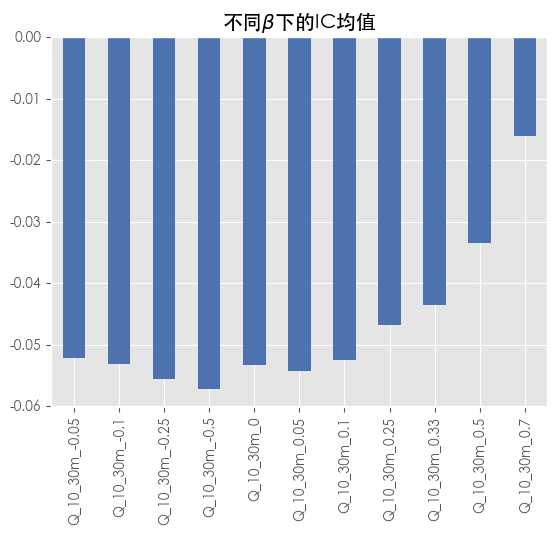

In [29]:
ic_df.mean().plot.bar(color='#4C72B0',title=r'不同$\beta$下的IC均值');

In [57]:
excess_ret = get_excess_ret(factor_data,factor_data.columns[:-1])

/var/folders/61/ld4fc0kj54j_9x51sdwrzh7w0000gn/T/ipykernel_96635/2591775622.py:32: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  ret_df = ret_df.reset_index().pivot_table(index='time',columns =x,values='next_ret')
/var/folders/61/ld4fc0kj54j_9x51sdwrzh7w0000gn/T/ipykernel_96635/2591775622.py:32: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  ret_df = ret_df.reset_index().pivot_table(index='time',columns =x,values='next_ret')
/var/folders/61/ld4fc0kj54j_9x51sdwrzh7w0000gn/T/ipykernel_96635/2591775622.py:32: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silenc

In [71]:
rebalance_date = _load_schedule()
rebalance_date = rebalance_date['rebalance_date']
rebalance_date = pd.to_datetime(rebalance_date)

benchmark_df = pd.read_csv('001sh.csv')
benchmark_df['trade_date'] = pd.to_datetime(benchmark_df['trade_date'])
benchmark_df = benchmark_df.set_index('trade_date').sort_index()

benchmark_df = benchmark_df.loc[rebalance_date.tolist()]
benchmark_ser = benchmark_df['close'].pct_change()[1:]
excess_ret['benchmark'] = benchmark_ser.values

<Axes: title={'center': '不同$\\beta$下的信息比率'}>

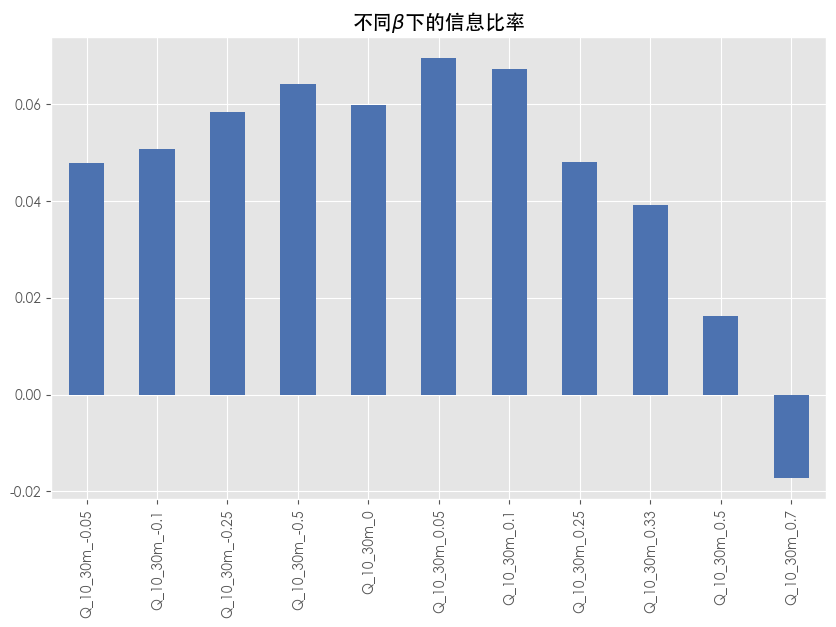

In [72]:
(risk_indicator_tear(excess_ret)['IR'].iloc[:-1]
                    .plot
                    .bar(color='#4C72B0',title=r'不同$\beta$下的信息比率',figsize=(10,6)))

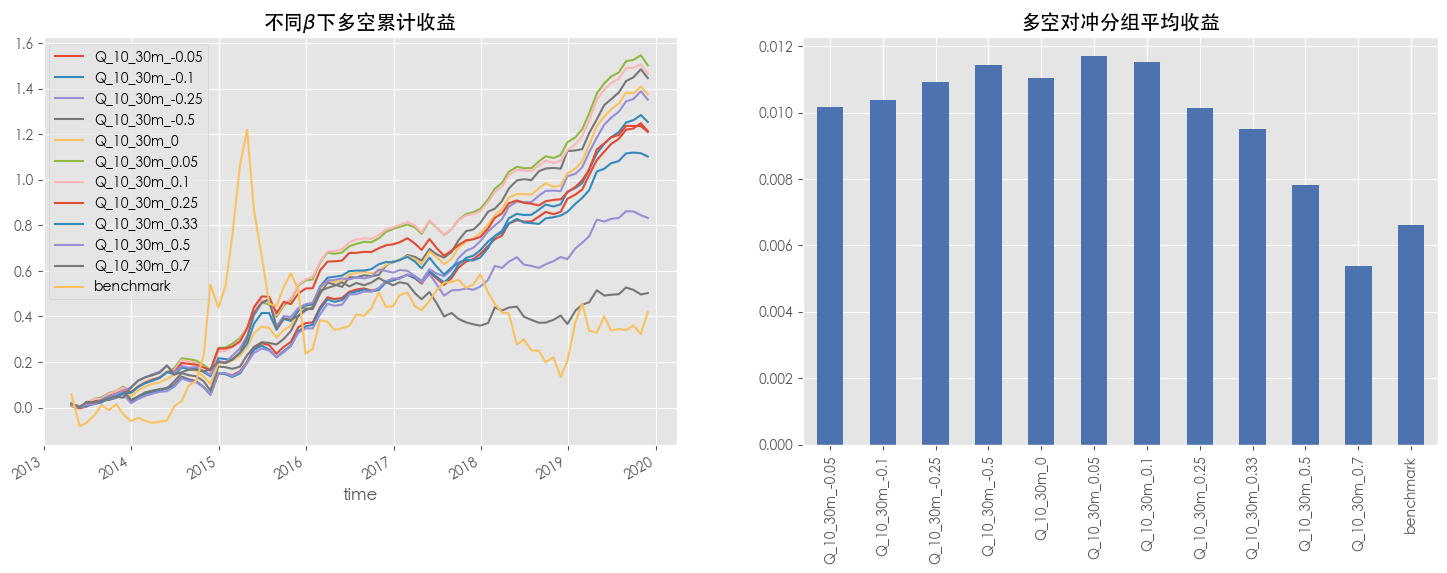

In [73]:
fig,cum_axes = plt.subplots(1,2,figsize=(18,6))

ep.cum_returns(excess_ret).plot(title=r'不同$\beta$下多空累计收益',ax=cum_axes[0])
excess_ret.mean().plot.bar(title='多空对冲分组平均收益',color='#4C72B0',ax=cum_axes[1]);

In [61]:
# TOKEN = "789696a2bb40aed04a4165edab1d6180d36a83b40259201771581f8f" 
# ts.set_token(TOKEN)
# pro = ts.pro_api()
# df = pro.index_daily(ts_code='000001.SH', start_date='20130401', end_date='20200228')
# df = df.sort_values('trade_date').reset_index(drop=True)
# df['trade_date'] = pd.to_datetime(df['trade_date'])
# df.set_index('trade_date', inplace=True)

# # 保存到本地，以后直接读
# df.to_csv('001sh.csv')